# Задача 2. Классификация состояния квартиры по тексту объявления

## 1. Постановка задачи

Мы работаем с платформой недвижимости Домклик. На таких площадках
карточку объявления заполняет сам продавец, поэтому зачастую мы имеем не полную информацию.
Зато текст описания люди пишут всегда довольно подробно (медиана около 1350 символов), 
и состояние квартиры можно хорошо отследть по нему.

Отсюда наша вторая задача: научиться по одному тексту описания определять состояние квартиры,
то есть класс ремонта (дизайнерский, евро, косметический, требует ремонта, без ремонта). Это нужно
сразу для трёх вещей:

1. автозаполнять пустое поле «Ремонт», чтобы каталог был полнее и фильтры поиска работали честно;
2. ловить расхождения между тем, что заявил продавец, и тем, что реально написано в тексте, и
   отправлять такие объявления на модерацию;
3. отдавать восстановленное состояние квартиры в оценщик цены из первой задачи: ремонт это один из
   заметных факторов цены, и когда поле пустое или враньё, оценка плывёт.

План такой: вторая модель приводит в порядок вход (чинит и проверяет признаки, спрятанные
в неструктурированном тексте), а первая по этому входу считает цену

На языке машинного обучения это многоклассовая классификация текста: 5 классов, русскоязычные
описания. Качество смотрим по accuracy и macro-F1. Macro-F1 здесь важен отдельно: классы
несбалансированы, а пропустить редкие «требует ремонта» и «без ремонта» опаснее всего, потому что
именно на них покупателя проще всего ввести в заблуждение.

Дальше сравниваем пять заметно разных нейросетевых архитектур на одних и тех же данных, по
нарастающей сложности: простой бейзлайн на усреднении эмбеддингов слов, затем TextCNN (свёртки, Kim 2014),
BiLSTM сattention, замороженный ruBERT-tiny2 с MLP-головой и, наконец, дообучаемый ruBERT-tiny2. 
Последние две модели опираются на предобученный трансформер, которых
в лекциях не было. 

Все запуски пишем в MLflow: метрики по эпохам плюс артефакты, чтобы потом можно
было воспроизвести предсказания без повторного обучения.


## 2. Окружение

In [1]:
!pip install -q torch mlflow transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os, re, json, copy, random, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import mlflow
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

DATA_PATH = 'data (6).csv'

mlflow.set_experiment('moscow-flats-text-repair')


device: cuda


2026/06/15 19:10:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/15 19:10:27 INFO mlflow.store.db.utils: Updating database tables
2026/06/15 19:10:29 INFO mlflow.tracking.fluent: Experiment with name 'moscow-flats-text-repair' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1781550629088, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781550629088, lifecycle_stage='active', name='moscow-flats-text-repair', tags={}, trace_location=None, workspace='default'>

## 3. Данные: тексты, метки и три источника утечки

Используется тот же датасет объявлений. Здесь берём только нужные
колонки: «Описание» (текст), «Ремонт» (метка), «Адрес» (группа для сплита),
«Цена»/«Площадь» (для бизнес-инсайтов).

Метки. Поле «Ремонт» содержит 19 сырых значений с дублями по регистру и синонимами -
сводим к 5 классам; маргинальные значения про отделку новостроек (<40 объектов) исключаем как другую сущность.

Перед обучением закрываем три источника утечки/тривиальности - каждый проверен на данных:

1. Дубли текстов (835 точных дублей: застройщики копируют описание для всех квартир корпуса);
   301 дубль пересекал бы train/test даже при групповом сплите, поэтому дедуплицируем по тексту.
2. Утечка через ЖК: квартиры одного дома имеют похожие описания, поэтому, как и в задаче 1,
   GroupShuffleSplit по адресу.
3. Прямое упоминание метки в тексте («дизайнерский ремонт» написан в 43% описаний своего
   класса), поэтому маскируем ремонто-специфичные формулировки токеном `маска`. Это превращает задачу
   из поиска ключевого слова в понимание контекста (паркет, мрамор, «заезжай и живи», «под себя»…).
   Влияние маскирования измерим явно - это отдельный инсайт.

In [ ]:
#числа в русской локали: 1 234,5 м2 превращаем в 1234.5
def num_ru(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    for ch in ['\u00a0', 'м²', 'м2', '%', ' ']:
        s = s.str.replace(ch, '', regex=False)
    s = s.str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

raw = pd.read_csv(DATA_PATH, sep=';', quotechar='"', engine='python', on_bad_lines='skip')
#в файле повторяются строки-заголовки (csv склеен из кусков) - выкидываем их
raw = raw[raw['Адрес'].astype(str).str.strip() != 'Адрес'].reset_index(drop=True)

df = pd.DataFrame()
df['price'] = pd.to_numeric(raw['Цена'], errors='coerce')
df['area_total'] = num_ru(raw['Площадь'])
df['repair_raw'] = (raw['Ремонт'].astype('string').str.strip().str.lower().replace({'евроремонт': 'евро'}))

#из адреса делаем группу для сплита (первые два уровня: город/улица), чтобы дом не утёк в test
addr = (raw['Адрес'].astype(str).str.replace('\u00a0', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True).str.strip())
df['addr_group'] = addr.str.split(',').str[:2].str.join(',').str.lower()
df['description'] = (raw['Описание'].fillna('').astype(str)
                     .str.replace(r'\s+', ' ', regex=True).str.strip())

#сырое поле "Ремонт" - это 19 значений с дублями по регистру и синонимами.
#сводим к 5 классам; редкие значения про отделку новостроек (<40 шт) считаем
#отдельной сущностью и выкидываем
CANON = {
    'дизайнерский': 'дизайнерский', 'дизайнерский ремонт': 'дизайнерский', 'авторский проект': 'дизайнерский',
    'евро': 'евро', 'под ключ': 'евро',
    'косметический': 'косметический', 'хороший': 'косметический', 'среднее': 'косметический',
    'требует ремонта': 'требует ремонта',
    'без ремонта': 'без ремонта', 'отсутствует': 'без ремонта', 'стройвариант': 'без ремонта',
    'под чистовой ремонт': 'без ремонта', 'чистовая': 'без ремонта',
}
df['label'] = df['repair_raw'].map(lambda x: CANON.get(x) if pd.notna(x) else None)

#слишком короткие описания (< 100 симв.) почти не несут смысла - отбрасываем
labeled = df[df['label'].notna() & (df['description'].str.len() >= 100)].copy()
unlabeled = df[df['label'].isna() & (df['description'].str.len() >= 100)].copy()  #кандидаты на автозаполнение

n0 = len(labeled)
labeled = labeled.drop_duplicates(subset='description').reset_index(drop=True)

print(f'размечено: было {n0}, стало {len(labeled)} после дедупликации текстов; '
      f'неразмеченных (кандидаты на автозаполнение): {len(unlabeled)}')

labeled['label'].value_counts()


размечено: 2839 -> 2788 после дедупликации текстов; неразмеченных (кандидаты на автозаполнение): 72


,count
label,
косметический,827
евро,726
дизайнерский,565
без ремонта,379
требует ремонта,291


In [5]:
#в описаниях продавцы часто прямо пишут класс ("дизайнерский ремонт") - это утечка
#метки в текст. Маскируем такие формулировки токеном "маска", чтобы модель училась
#по контексту, а не искала ключевое слово
MASK_RE = (r'(?:дизайнерск\w+|авторск\w+|евро[- ]?ремонт\w*|косметическ\w+|'
           r'капитальн\w+\s+ремонт\w*|требует\w*\s+ремонт\w*|под ремонт|'
           r'без ремонта|без отделки|черновая отделка|черновой)')

def prepare_text(s: pd.Series, mask=True) -> pd.Series:
    t = s.str.lower()
    if mask:
        t = t.str.replace(MASK_RE, ' маска ', regex=True)
    return t

labeled['text'] = prepare_text(labeled['description'])

#на всякий случай проверим, что прямых упоминаний классов не осталось
for cls, pat in [('дизайнерский', r'дизайнерск'), ('евро', r'евро[- ]?ремонт'),
                 ('косметический', r'косметическ'), ('без ремонта', r'без ремонта')]:
    share = labeled.loc[labeled['label'] == cls, 'text'].str.contains(pat).mean()
    assert share == 0.0, cls
print('маскирование ок: прямых упоминаний классов в текстах не осталось')


маскирование ок: прямых упоминаний классов в текстах не осталось


In [ ]:
#групповой сплит 70/15/15 по адресу. Сначала отрезаем 30% (val+test), потом делим пополам
y_str = labeled['label'].values
groups = labeled['addr_group'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
idx_tr, rest = next(gss.split(np.arange(len(labeled)).reshape(-1, 1), y_str, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
va_i, te_i = next(gss2.split(rest.reshape(-1, 1), y_str[rest], groups[rest]))
idx_va, idx_te = rest[va_i], rest[te_i]

print(f'train={len(idx_tr)}  val={len(idx_va)}  test={len(idx_te)}')

le = LabelEncoder().fit(y_str[idx_tr])
CLASSES = list(le.classes_)
y = le.transform(y_str)
print('классы:', CLASSES)

def clf_metrics(y_true, y_pred):
    return {'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro'))}


train=1701  val=591  test=496
классы: ['без ремонта', 'дизайнерский', 'евро', 'косметический', 'требует ремонта']


## 4. EDA текстов

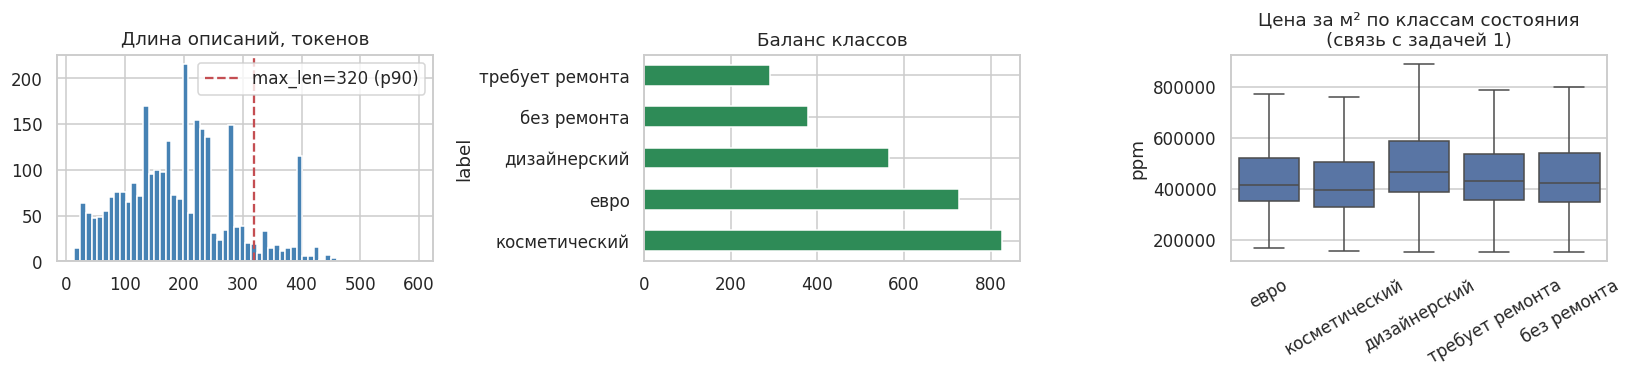

медианная длина 189 токенов, p90 = 323


In [ ]:
tok_len = labeled['text'].str.findall(r'[а-яёa-z0-9]+').str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(tok_len, bins=60, color='steelblue')
axes[0].axvline(320, color='r', ls='--', label='max_len=320 (p90)')
axes[0].set_title('Длина описаний, токенов')
axes[0].legend()

labeled['label'].value_counts().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Баланс классов')

sns.boxplot(data=labeled.assign(ppm=labeled['price'] / labeled['area_total']), x='label', y='ppm', ax=axes[2], showfliers=False)

axes[2].set_title('Цена за м² по классам состояния')
axes[2].tick_params(axis='x', rotation=30)
plt.show()

print(f'медианная длина {int(tok_len.median())} токенов, p90 = {int(tok_len.quantile(0.9))}')


Классы умеренно несбалансированы (от ±950 «требует ремонта» до ±2200 «косметический») -
используем взвешенный лосс и macro-F1. Цена за м² монотонно связана с классом состояния -
прямое подтверждение ценности этого признака для оценщика из задачи 1.

In [ ]:
#смотрим, какие слова отличают классы - чистая статистика частот, без модели.
#Метрика: лог-отношение "доля документов класса со словом" к "доле в остальных".
TOKEN_RE = re.compile(r'[а-яёa-z0-9]+')
def tokenize(s):
    return TOKEN_RE.findall(s)

def class_word_counts(cls):
    cnt = Counter()
    for t in labeled.loc[labeled['label'] == cls, 'text'].iloc[:3000]:
        cnt.update(set(tokenize(t)))   #set, значит считаем по документам, а не по вхождениям
    return cnt

per_cls, all_cnt = {}, Counter()
for cls in labeled['label'].dropna().unique():
    per_cls[cls] = class_word_counts(cls)
    all_cnt.update(per_cls[cls])

n_cls = {cls: (labeled['label'] == cls).sum() for cls in per_cls}
for cls, cnt in per_cls.items():
    #+1 в знаменателе - сглаживание, чтобы редкое слово не дало бесконечный скор
    scores = {w: (c / n_cls[cls]) / ((all_cnt[w] - c + 1) / (len(labeled) - n_cls[cls]))
              for w, c in cnt.items() if all_cnt[w] >= 30}
    top = sorted(scores, key=scores.get, reverse=True)[:10]
    print(f'{cls:>16}: {", ".join(top)}')


            евро: ухоженная, качественным, качественный, делали, встроенная, бытовая, альтернативная, стоимости, посудомоечная, сделан
   косметический: застекленный, хорошие, панельного, хорошее, распашонка, пассажирским, альтернатива, застекленная, спальном, любую
    дизайнерский: стильная, душевой, кровать, постирочная, мелочей, натурального, качества, диван, столовая, укомплектована
 требует ремонта: митино, пятницкое, соседству, парках, воплотить, гулять, идеи, машиномест, отсюда, трёх
     без ремонта: идеи, обустроить, сдан, вкусу, своему, воплотить, санузлы, отделки, мечты, реализовать


Различительная лексика осмысленна даже после маскирования (материалы, мебель, формулировки
про состояние) - сигнал распределён по контексту, значит, у моделей, понимающих сочетания и
порядок слов, есть пространство для выигрыша над простым усреднением.

## 5. Токенизация для собственных архитектур

Для собственных архитектур (TextCNN, BiLSTM) - словная токенизация со словарём по train (частота >= 3, ±15 тыс. слов), паддинг/обрезка до `MAX_LEN = 320` (покрывает 90% текстов).
Индекс 0 - паддинг, 1 - неизвестное слово. Для трансформера используется его собственныйтокенизатор

In [ ]:
MAX_LEN = 320

#словарь слово-индекс по train. 0 это паддинг, 1 это неизвестное слово
class WordVocab:
    def __init__(self, texts, min_freq=3):
        cnt = Counter()
        for t in texts:
            cnt.update(tokenize(t))
        
        #оставляем слова с частотой >= 3, иначе словарь раздувается опечатками
        self.itos = ['<pad>', '<unk>'] + [w for w, c in cnt.most_common() if c >= min_freq]
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text, max_len=MAX_LEN):
        ids = [self.stoi.get(w, 1) for w in tokenize(text)][:max_len]
        return ids + [0] * (max_len - len(ids))   #добиваем паддингом до max_len

    def __len__(self):
        return len(self.itos)

vocab = WordVocab(labeled['text'].iloc[idx_tr])   #строим только по train
print('размер словаря:', len(vocab))

ids_all = torch.tensor(np.stack([vocab.encode(t) for t in labeled['text']]), dtype=torch.long)
y_t = torch.tensor(y, dtype=torch.long)
print('тензор токенов:', tuple(ids_all.shape))


## 6. Архитектуры: бейзлайн на усреднении эмбеддингов, TextCNN и BiLSTM + attention

Бейзлайн на усреднении эмбеддингов (класс `MeanEmbeddingBaseline`): просто усредняем обучаемые эмбеддингивсех слов и сверху ставим линейный слой. Это самая примитивная нейросеть для текста, она полностью игнорирует порядок слов, никаких свёрток и рекуррентности тут нет. Нужна как точка отсчёта:
всё, что более сложные архитектуры выигрывают у неё, и есть вклад структуры текста, а не просто набора слов.

TextCNN (Kim, 2014): параллельные 1-D свёртки с окнами 2/3/4/5 слов над матрицей эмбеддингов и global max-pooling. По сути детектор локальных фраз-индикаторов («натяжные потолки», «требуется замена»)

BiLSTM + additive attention: двунаправленная LSTM читает текст целиком, attention-пулинг взвешивает скрытые сотояния. Это модель порядка слов и дальних зависимостей, а attention заодно даёт интерпретируемость, т.к., какие слова повлияли на решение.


In [ ]:
#простой бейзлайн: усредняем эмбеддинги слов и сверху линейный слой. Порядок слов полностью
#игнорируется (никаких свёрток/рекуррентности)
class MeanEmbeddingBaseline(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_emb, n_classes)

    def forward(self, ids):
        mask = (ids != 0).unsqueeze(-1).float()
        e = self.emb(ids)
        mean = (e * mask).sum(1) / mask.sum(1).clamp(min=1.0)
        return self.fc(self.dropout(mean))


#Kim 2014: параллельные свёртки с окнами 2/3/4/5 слов и max-pooling.
#По сути детектор локальных фраз-индикаторов ("натяжные потолки", "требуется замена")
class TextCNN(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, n_filters=128, kernel_sizes=(2, 3, 4, 5), dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(d_emb, n_filters, k, padding=k // 2) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernel_sizes), n_classes)

    def forward(self, ids):
        x = self.emb(ids).transpose(1, 2)
        feats = [torch.relu(c(x)).max(dim=2).values for c in self.convs]
        return self.fc(self.dropout(torch.cat(feats, dim=1)))


#Двунаправленная LSTM с attention-пулингом. В отличие от CNN читает текст целиком и ловит
#дальние зависимости, а attention заодно показывает, какие слова повлияли на ответ
class BiLSTMAttn(nn.Module):
    def __init__(self, vocab_size, n_classes, d_emb=128, d_hidden=128, n_layers=1, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.lstm = nn.LSTM(d_emb, d_hidden, num_layers=n_layers, batch_first=True, bidirectional=True, dropout=dropout if n_layers > 1 else 0.0)
        
        self.attn = nn.Linear(2 * d_hidden, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * d_hidden, n_classes)

    def forward(self, ids):
        mask = (ids != 0)
        h, _ = self.lstm(self.emb(ids))
        scores = self.attn(h).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        w = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (h * w).sum(dim=1)
        return self.fc(self.dropout(pooled))


## 7. Архитектуры 3-4: предобученный трансформер ruBERT-tiny2

[`cointegrated/rubert-tiny2`](https://huggingface.co/cointegrated/rubert-tiny2) - русскоязычный BERT библиотека HuggingFace `transformers`

Два принципиально разных режима использования - их сравнение само по себе содержательный вывод:
- (3) frozen: BERT заморожен и используется как экстрактор признаков (mean-pooling скрытых состояний даёт вектор 312), сверху обучается только MLP-голова. Дёшево, эмбеддинги считаются один раз;
- (4) fine-tuning: дообучаются все веса BERT под задачу (малый lr = 2e-5, linear warmup, 3-6 эпох) - дороже, но модель адаптирует само представление языка под доменную лексику объявлений.

In [ ]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

BERT_NAME = 'cointegrated/rubert-tiny2'
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)

def bert_encode(texts, max_len=MAX_LEN):
    enc = bert_tokenizer(list(texts), padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    
    return enc['input_ids'], enc['attention_mask']

bert_ids, bert_mask = bert_encode(labeled['text'])
print('BERT-токены:', tuple(bert_ids.shape))


#mean-pooling замороженного BERT. Считаем один раз, дальше учим только голову, поэтому быстро
@torch.no_grad()
def bert_frozen_embeddings(ids, mask, batch_size=64):
    bert = AutoModel.from_pretrained(BERT_NAME).to(DEVICE).eval()
    out = []
    for i in range(0, len(ids), batch_size):
        b_ids = ids[i:i + batch_size].to(DEVICE)
        b_mask = mask[i:i + batch_size].to(DEVICE)
        h = bert(input_ids=b_ids, attention_mask=b_mask).last_hidden_state
        
        m = b_mask.unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1)).cpu())
        
    del bert
    
    torch.cuda.empty_cache()
    return torch.cat(out)

frozen_emb = bert_frozen_embeddings(bert_ids, bert_mask)
print('frozen-эмбеддинги:', tuple(frozen_emb.shape))


#голова поверх замороженных эмбеддингов BERT. BERT тут просто экстрактор признаков
class FrozenBertMLP(nn.Module):
    def __init__(self, d_in, n_classes, hidden=(256, 128), dropout=0.3):
        super().__init__()
        layers, d = [], d_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(dropout)]
            d = h
            
        self.net = nn.Sequential(*layers, nn.Linear(d, n_classes))

    def forward(self, emb):
        return self.net(emb)


#дообучаем весь BERT под задачу. Дороже, зато представление адаптируется под домен
class BertFineTune(nn.Module):
    def __init__(self, n_classes, model_name=BERT_NAME):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=n_classes)

    def forward(self, ids, mask):
        return self.bert(input_ids=ids, attention_mask=mask).logits
